In [1]:
!pip install feature-engine
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.7 MB/s eta 0:00:00


In [2]:
# Bibliotecas padrão
import os

# Bibliotecas de terceiros
import numpy as np
import pandas as pd
import shap

# Scikit-learn
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import VarianceThreshold, SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)

# Feature-engine
from feature_engine.selection import SmartCorrelatedSelection
from feature_engine.transformation import LogCpTransformer

# LightGBM
from lightgbm import LGBMClassifier

# Skopt (Bayesian optimization)
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Configurações
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
set_config(transform_output='pandas')


In [3]:
ROOT = "/content/drive/MyDrive/ml-project"
FILE = "smart-contract-dataset.csv"
SEED = 78

In [4]:
data = pd.read_csv(os.path.join(ROOT, "data", FILE))

In [5]:
data = data.rename(
    columns=lambda col: (
        col
        .replace('<', 'lt')
        .replace('>', 'gt')
        .replace('__', '_double_underscore')
        .replace(':', 'colon')
    )
)

In [6]:
more_features = pd.read_csv(f"{ROOT}/data/solidity_word_counts.csv")

In [7]:
data = pd.merge(
    data,
    more_features,
    on='hash_id'
)

In [8]:
X = data.iloc[:, 3:].select_dtypes(include="number")
y = data.label

In [9]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=SEED
)

print(X_train.shape, X_val.shape, X_test.shape)

(23468, 344) (5868, 344) (7335, 344)


In [10]:
OPCODE_CATEGORIES = {
    'Arithmetic': ['ADD', 'MUL', 'SUB', 'DIV', 'SDIV', 'MOD', 'SMOD', 'ADDMOD', 'MULMOD', 'EXP', 'SIGNEXTEND'],
    'ComparisonLogic': ['LT', 'GT', 'SLT', 'SGT', 'EQ', 'ISZERO', 'AND', 'OR', 'XOR', 'NOT', 'BYTE', 'SHL', 'SHR', 'SAR'],
    'Hashing': ['SHA3'],
    'Environmental': [
        'ADDRESS', 'BALANCE', 'ORIGIN', 'CALLER', 'CALLVALUE',
        'CALLDATALOAD', 'CALLDATASIZE', 'CALLDATACOPY',
        'CODESIZE', 'CODECOPY',
        'GASPRICE', 'EXTCODESIZE', 'EXTCODECOPY', 'RETURNDATASIZE',
        'RETURNDATACOPY', 'BLOCKHASH', 'COINBASE', 'TIMESTAMP',
        'NUMBER', 'DIFFICULTY', 'GASLIMIT',
        'GAS'
    ],
    'Stack_PUSH': [f'PUSH{i}' for i in range(1, 33)],
    'Stack_DUP': [f'DUP{i}' for i in range(1, 17)],
    'Stack_SWAP': [f'SWAP{i}' for i in range(1, 17)],
    'Stack_POP': ['POP'],
    'Memory': ['MLOAD', 'MSTORE', 'MSTORE8', 'MSIZE'],
    'Storage': ['SLOAD', 'SSTORE'],
    'FlowControl': ['JUMP', 'JUMPI', 'PC', 'JUMPDEST', 'STOP'],
    'CallOps': ['CREATE', 'CALL', 'CALLCODE', 'DELEGATECALL', 'STATICCALL'],
    'ReturnOps': ['RETURN', 'REVERT'],
    'Logging': [f'LOG{i}' for i in range(5)], # LOG0, LOG1, LOG2, LOG3, LOG4
    'System': ['INVALID', 'SELFDESTRUCT']
}


class OpcodeAggregator(BaseEstimator, TransformerMixin):
    def __init__(self, opcode_categories, drop_original=True):
        self.opcode_categories = opcode_categories
        self.drop_original = drop_original
        self.opcode_weight_prefix = 'Opcode weight '
        self._feature_names_out = []

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self.feature_names_in_ = list(X.columns)

        self._original_opcode_cols_processed = set()
        for cat_name, opcode_suffixes_in_cat in self.opcode_categories.items():
            for suffix in opcode_suffixes_in_cat:
                col_name = f'{self.opcode_weight_prefix}{suffix}'
                if col_name in self.feature_names_in_:
                    self._original_opcode_cols_processed.add(col_name)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X_transformed = pd.DataFrame(X, columns=self.feature_names_in_)
        else:
            X_transformed = X.copy()

        self._aggregated_feature_names_created = []

        for cat_name, opcode_suffixes_in_cat in self.opcode_categories.items():
            current_cat_opcode_cols_present = []
            for suffix in opcode_suffixes_in_cat:
                col_name = f'{self.opcode_weight_prefix}{suffix}'
                if col_name in X_transformed.columns:
                    current_cat_opcode_cols_present.append(col_name)

            if current_cat_opcode_cols_present:
                new_col_name = f'Agg_Opcode_{cat_name}'
                X_transformed[new_col_name] = X_transformed[current_cat_opcode_cols_present].sum(axis=1)
                self._aggregated_feature_names_created.append(new_col_name)

        if self.drop_original:
            cols_to_drop = [
                col for col in self._original_opcode_cols_processed if col in X_transformed.columns
            ]
            X_transformed = X_transformed.drop(columns=cols_to_drop, errors='ignore')

        self._feature_names_out = list(X_transformed.columns)

        return X_transformed

    def get_feature_names_out(self, input_features=None):
        if hasattr(self, '_feature_names_out') and self._feature_names_out:
            return self._feature_names_out

        if not hasattr(self, 'feature_names_in_'):
             raise AttributeError(
                "This OpcodeAggregator instance is not fitted yet. "
                "Call 'fit' with appropriate arguments before using this estimator."
            )

        temp_output_features = list(self.feature_names_in_)

        if self.drop_original:
            temp_output_features = [
                col for col in temp_output_features if col not in self._original_opcode_cols_processed
            ]

        for cat_name in self.opcode_categories.keys():
            has_constituent_opcode = False
            for suffix in self.opcode_categories[cat_name]:
                 if f'{self.opcode_weight_prefix}{suffix}' in self.feature_names_in_:
                     has_constituent_opcode = True
                     break
            if has_constituent_opcode:
                 temp_output_features.append(f'Agg_Opcode_{cat_name}')

        return list(dict.fromkeys(temp_output_features))

    def get_feature_names_out(self, input_features=None):
        if hasattr(self, '_feature_names_out') and self._feature_names_out:
            return self._feature_names_out

        if not hasattr(self, 'feature_names_in_'):
            raise AttributeError(
                "This OpcodeAggregator instance is not fitted yet. "
                "Call 'fit' with appropriate arguments before using this estimator."
            )

        temp_output_features = list(self.feature_names_in_)

        if self.drop_original:
            temp_output_features = [
                col for col in temp_output_features if col not in self._original_opcode_cols_processed
            ]
        for cat_name in self._categories_to_create:
            temp_output_features.append(f'Agg_Opcode_{cat_name}')

        return list(dict.fromkeys(temp_output_features))


class FlagSparseFeatures(BaseEstimator, TransformerMixin):
    """
    A simplified transformer to create binary presence flags for specified or highly sparse numeric features.
    Allows choosing columns and whether to keep original sparse columns.
    Optimized to reduce DataFrame fragmentation.
    """
    def __init__(self, sparsity_threshold=0.75, columns_to_transform=None, keep_original=False):
        """
        Initialize the transformer.

        Parameters:
        sparsity_threshold (float): Proportion of zeros to consider a column sparse.
        columns_to_transform (list of str, optional): Specific columns to consider.
                                                    If None, all numeric columns are considered.
        keep_original (bool): If True, keeps original sparse columns; otherwise, drops them.
        """
        self.sparsity_threshold = sparsity_threshold
        self.columns_to_transform = columns_to_transform
        self.keep_original = keep_original

    def fit(self, X, y=None):
        """
        Identify sparse numeric columns to be transformed.
        """
        if not isinstance(X, pd.DataFrame):
            X_df = pd.DataFrame(X)
        else:
            X_df = X

        self.feature_names_in_ = np.array(X_df.columns, dtype=object)
        self.sparse_cols_ = []

        candidate_cols = []
        if self.columns_to_transform is None:
            candidate_cols = X_df.select_dtypes(include=np.number).columns.tolist()
        else:
            missing_cols = [col for col in self.columns_to_transform if col not in X_df.columns]
            if missing_cols:
                warnings.warn(f"Warning: Columns {missing_cols} not found in input DataFrame during fit. They will be ignored.")
            candidate_cols = [col for col in self.columns_to_transform if col in X_df.columns]

        for col in candidate_cols:
            if pd.api.types.is_numeric_dtype(X_df[col]):
                try:
                    sparsity = (X_df[col] == 0).mean()
                    if sparsity >= self.sparsity_threshold:
                        self.sparse_cols_.append(col)
                except TypeError:
                    pass

        return self

    def transform(self, X):
        """
        Transform data by adding presence flags and optionally dropping original columns.
        """
        check_is_fitted(self, 'sparse_cols_')

        if not isinstance(X, pd.DataFrame):
            X_transformed = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        else:
            X_transformed = X.copy()

        new_flags_data = {}

        for col in self.sparse_cols_:
            if col in X_transformed.columns:
                flag_name = f"{col}_presence"
                try:
                    new_flags_data[flag_name] = (X_transformed[col] > 0).astype(int)
                except TypeError:
                    # Silently ignore if a column became non-numeric between fit and transform
                    pass

        if new_flags_data:
            flags_df = pd.DataFrame(new_flags_data, index=X_transformed.index)
            X_transformed = pd.concat([X_transformed, flags_df], axis=1)

        if not self.keep_original:
            cols_to_drop = [col for col in self.sparse_cols_ if col in X_transformed.columns]
            if cols_to_drop:
                X_transformed = X_transformed.drop(columns=cols_to_drop)

        return X_transformed

In [28]:
lightgbm_hyperparameters = {
    "objective": "binary",
    "metric": "aucpr",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 20,
    "min_child_weight": 1e-3,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "n_estimators": 500,
    "verbosity": -1,
    "random_state": SEED
}


feature_reduction_pipeline = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=0.0001
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureReduction", feature_reduction_pipeline
        ),
        (
            "LogCpTransformer", LogCpTransformer(
                C=1
            )
        ),
        (
            "FlagSparseFeatures", FlagSparseFeatures(
                sparsity_threshold=0.9
            )
        )
    ]
)


training_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", LGBMClassifier(
                **lightgbm_hyperparameters
            )
        )
    ]
)


In [14]:
training_pipeline.fit(X_train, y_train)
y_pred = training_pipeline.predict(X_val)

In [15]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4238
           1       0.59      0.69      0.64      1630

    accuracy                           0.78      5868
   macro avg       0.73      0.75      0.74      5868
weighted avg       0.79      0.78      0.79      5868



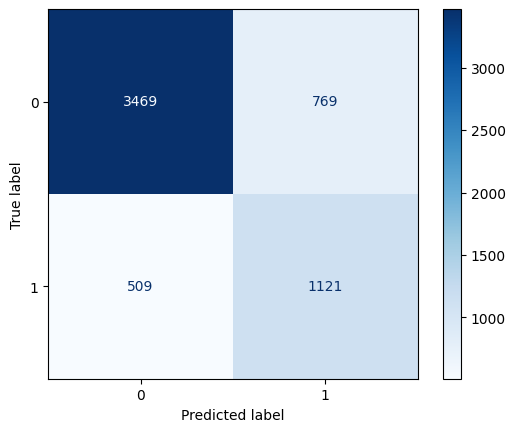

In [16]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues');

In [29]:
search_space = {
    "Preprocessing__FeatureReduction__VarianceThreshold__threshold": Real(1e-6, 1e-2, prior="log-uniform"),
    "Preprocessing__FeatureReduction__SmartCorrelatedSelection__threshold": Real(0.7, 0.99, prior="uniform"),

    "Classifier__learning_rate": Real(0.01, 0.2, prior="log-uniform"),
    "Classifier__max_depth": Integer(3, 10),
    "Classifier__min_child_samples": Integer(1, 100),
    "Classifier__min_split_gain": Real(0, 5.0),
    "Classifier__bagging_fraction": Real(0.5, 1.0),
    "Classifier__feature_fraction": Real(0.5, 1.0),
    "Classifier__reg_lambda": Real(1e-3, 10.0, prior="log-uniform"),
    "Classifier__reg_alpha": Real(1e-3, 10.0, prior="log-uniform"),
    "Classifier__n_estimators": Integer(100, 500),
    "Classifier__scale_pos_weight": Real(1.0, 10.0),
    "Classifier__num_leaves": Integer(10, 300),
    "Classifier__min_data_in_leaf": Integer(1, 100),
    "Classifier__bagging_freq": Integer(1, 10),
}

In [26]:
cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [30]:
bayesian_optimization = BayesSearchCV(
    estimator=training_pipeline,
    search_spaces=search_space,
    scoring="f1",
    cv=cross_validation,
    n_iter=50,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    random_state=SEED
)
bayesian_optimization.fit(X_train_val, y_train_val)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

BayesSearchCV(cv=StratifiedKFold(n_splits=5, random_state=78, shuffle=True),
              estimator=Pipeline(steps=[('Preprocessing',
                                         Pipeline(steps=[('FeatureReduction',
                                                          Pipeline(steps=[('OpcodeAggregator',
                                                                           OpcodeAggregator(opcode_categories={'Arithmetic': ['ADD',
                                                                                                                              'MUL',
                                                                                                                              'SUB',
                                                                                                                              'DIV',
                                                                                                                              'SDIV',
                                                                                                                              'MOD',
                                                                                                                              'SMOD',
                                                                                                                              'ADDMOD',
                                                                                                                              'MULMOD',
                                                                                                                              'EXP',
                                                                                                                              'SIGNEXTEND'],
                                                                                                               'CallOps': ['CREATE',
                                                                                                                           'CALL',
                                                                                                                           'C...
                             'Classifier__scale_pos_weight': Real(low=1.0, high=10.0, prior='uniform', transform='normalize'),
                             'Preprocessing__FeatureReduction__SmartCorrelatedSelection__threshold': Real(low=0.7, high=0.99, prior='uniform', transform='normalize'),
                             'Preprocessing__FeatureReduction__VarianceThreshold__threshold': Real(low=1e-06, high=0.01, prior='log-uniform', transform='normalize')},
              verbose=1)

In [31]:
best_model = bayesian_optimization.best_estimator_

best_params = bayesian_optimization.best_params_

best_score = bayesian_optimization.best_score_

results_df = pd.DataFrame(bayesian_optimization.cv_results_)

In [32]:
best_score

np.float64(0.6157924290799153)

In [43]:
best_params

OrderedDict([('Classifier__bagging_fraction', 0.6028712846116155),
             ('Classifier__bagging_freq', 10),
             ('Classifier__feature_fraction', 0.6765687661851643),
             ('Classifier__learning_rate', 0.0741762928921257),
             ('Classifier__max_depth', 10),
             ('Classifier__min_child_samples', 78),
             ('Classifier__min_data_in_leaf', 57),
             ('Classifier__min_split_gain', 0.0),
             ('Classifier__n_estimators', 443),
             ('Classifier__num_leaves', 300),
             ('Classifier__reg_alpha', 0.001),
             ('Classifier__reg_lambda', 10.0),
             ('Classifier__scale_pos_weight', 3.3607499925572917),
             ('Preprocessing__FeatureReduction__SmartCorrelatedSelection__threshold',
              0.8474568335095916),
             ('Preprocessing__FeatureReduction__VarianceThreshold__threshold',
              0.0006632522060533792)])

In [41]:
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_Classifier__bagging_fraction,param_Classifier__bagging_freq,param_Classifier__feature_fraction,param_Classifier__learning_rate,param_Classifier__max_depth,param_Classifier__min_child_samples,param_Classifier__min_data_in_leaf,param_Classifier__min_split_gain,param_Classifier__n_estimators,param_Classifier__num_leaves,param_Classifier__reg_alpha,param_Classifier__reg_lambda,param_Classifier__scale_pos_weight,param_Preprocessing__FeatureReduction__SmartCorrelatedSelection__threshold,param_Preprocessing__FeatureReduction__VarianceThreshold__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score,rank_train_score
0,9.339010,1.217669,0.515571,0.173723,0.730778,10,0.762764,0.024094,4,9,20,2.648097,443,265,0.001541,0.316729,4.423383,0.936777,0.000379,{'Classifier__bagging_fraction': 0.73077782125...,0.549441,0.554967,0.550344,0.560708,0.553560,0.553804,0.004002,38,0.587606,0.582353,0.586945,0.588748,0.582353,0.585601,0.002714,39
1,11.086072,2.014973,0.553484,0.056467,0.760683,2,0.820254,0.039146,7,1,82,4.403315,469,278,0.013968,0.015577,5.673842,0.766643,0.000169,{'Classifier__bagging_fraction': 0.76068252246...,0.550987,0.560471,0.554873,0.560907,0.561503,0.557748,0.004134,34,0.617913,0.615884,0.612161,0.611015,0.611301,0.613655,0.002751,34
2,8.834822,1.343299,0.452887,0.081727,0.537109,6,0.632985,0.115374,8,83,29,1.924834,359,149,0.365008,0.633900,2.170576,0.839919,0.000156,{'Classifier__bagging_fraction': 0.53710885253...,0.599450,0.595668,0.603845,0.604927,0.611889,0.603156,0.005471,5,0.795489,0.798756,0.797579,0.799634,0.797579,0.797807,0.001394,7
3,12.936994,1.962422,0.608146,0.135514,0.514327,2,0.888443,0.056337,8,34,61,1.136385,441,53,0.004078,6.222294,4.928179,0.867729,0.000382,{'Classifier__bagging_fraction': 0.51432748850...,0.594136,0.592124,0.587634,0.599657,0.598270,0.594364,0.004327,14,0.739302,0.743268,0.733742,0.736222,0.735091,0.737525,0.003408,14
4,6.691152,1.421404,0.302597,0.021429,0.874510,6,0.825109,0.072061,4,84,10,3.071642,233,182,0.001133,0.002628,3.458398,0.918845,0.001405,{'Classifier__bagging_fraction': 0.87451035867...,0.570579,0.582609,0.571004,0.585899,0.591077,0.580234,0.008170,22,0.636224,0.635908,0.638512,0.635079,0.638862,0.636917,0.001497,26
5,4.831260,0.849077,0.272866,0.088720,0.959235,1,0.962205,0.174735,9,15,71,2.699098,154,160,0.026335,0.145062,5.003878,0.729754,0.003495,{'Classifier__bagging_fraction': 0.95923501407...,0.553787,0.571552,0.561572,0.569960,0.565908,0.564556,0.006401,32,0.640044,0.648524,0.642079,0.655588,0.635760,0.644399,0.006945,25
6,7.746490,1.654931,0.260689,0.049070,0.772186,7,0.893847,0.075902,7,36,85,4.521362,444,180,2.571585,0.514973,1.885442,0.825556,0.000002,{'Classifier__bagging_fraction': 0.77218626350...,0.567958,0.579183,0.568551,0.588957,0.565617,0.574053,0.008798,29,0.624739,0.623499,0.622959,0.621093,0.611862,0.620830,0.004635,32
7,12.025929,1.700753,0.284113,0.043791,0.930428,2,0.582746,0.107112,6,59,23,4.920067,463,34,0.006118,0.306459,7.328496,0.964914,0.008401,{'Classifier__bagging_fraction': 0.93042763705...,0.524922,0.535331,0.529173,0.538547,0.539771,0.533549,0.005665,42,0.572151,0.571228,0.567373,0.572528,0.569317,0.570519,0.001926,41
8,14.403375,2.119539,0.380459,0.077104,0.836334,7,0.526588,0.084275,3,77,42,2.324117,430,255,0.083263,0.307281,2.123047,0.909992,0.000004,{'Classifier__bagging_fraction': 0.83633411639...,0.575851,0.578116,0.586896,0.594894,0.588976,0.584947,0.007048,21,0.652968,0.645477,0.651879,0.647433,0.642813,0.648114,0.003828,24
9,14.907404,2.949491,0.698879,0.207958,0.679866,10,0.987371,0.012936,10,43,88,1.620698,361,117,0.010910,0.295083,2.909016,0.869870,0.000014,{'Classifier__bagging_fraction': 0.67986636118...,0.595968,0.603064,0.590934,0.610

In [35]:
import cloudpickle

with open(os.path.join(ROOT, 'models',"lightgbm_pipeline.pkl"), "wb") as f:
    cloudpickle.dump(best_model, f)

In [36]:
results_df.to_csv(os.path.join(
    ROOT, "results", "results-pipeline_lightgbm.csv"), index=False
)

In [37]:
y_pred = best_model.predict(X_test)

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      5410
           1       0.55      0.72      0.63      1925

    accuracy                           0.77      7335
   macro avg       0.72      0.76      0.73      7335
weighted avg       0.80      0.77      0.78      7335



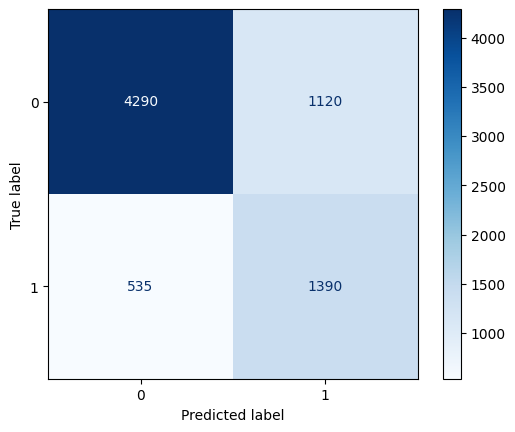

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues');